# MNIST Net from Scratch

In [ ]:
# Input images: 784 pixels, values in [0, 255]
# Size of input images: 28x28 pixels
# 10 target classes: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

# Neural Network Size: (input) --> 784 --> 64 --> 10 --> (output)

## Math

#### Forward Propagation

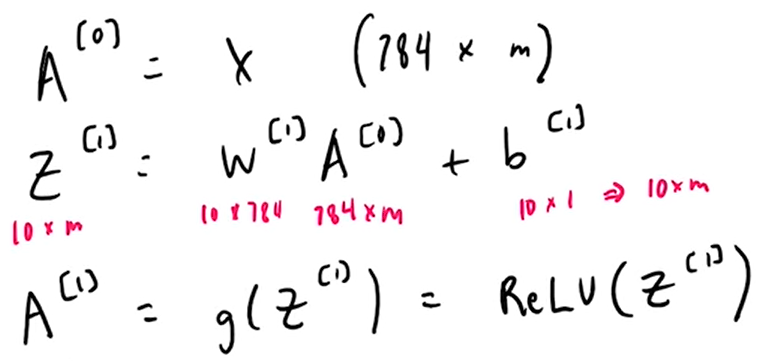

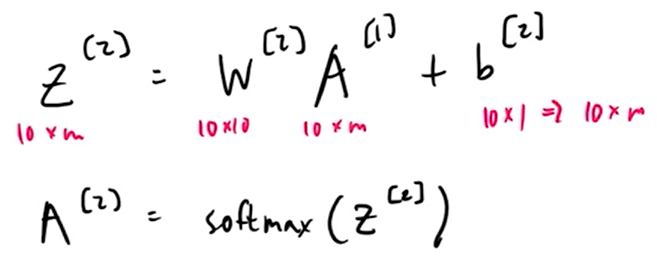

#### Backward Propagation

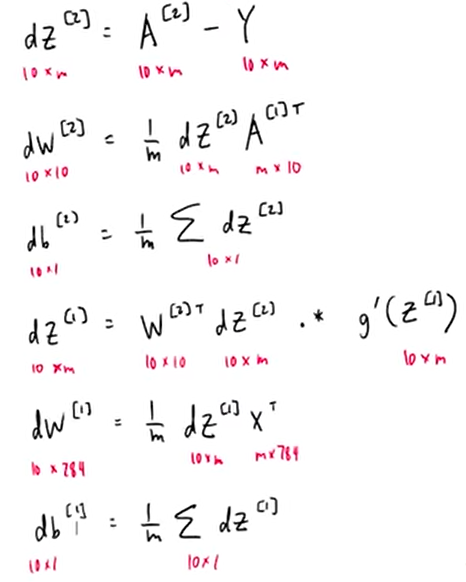

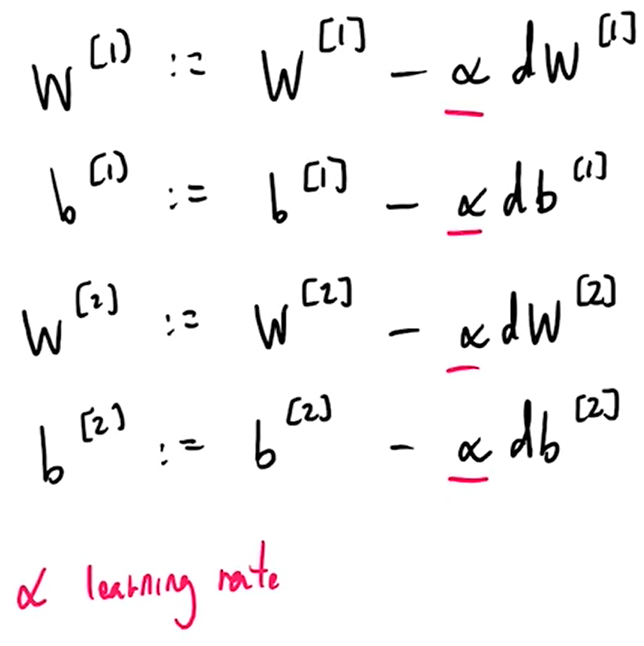

## Coding

In [1]:
# import numpy as np
# numpy su gpu
import cupy as np
import pandas as pd
import matplotlib.pyplot as plt
np.cuda.set_allocator(np.cuda.MemoryPool().malloc)

### Data Engineering

In [2]:
data_train = pd.read_csv('mnist_train.csv')
data_test = pd.read_csv('mnist_test.csv')

In [28]:
data_train

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data_test

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Data Splitting

data_train = np.array(data_train)
np.random.shuffle(data_train)

data_test = np.array(data_test)
np.random.shuffle(data_test)

# calcola la trasposta (features --> righe ; istanze --> colonne)
# serve per il dot-product nella forward (moltiplicazione matrici)
data_train = data_train.T
X_train = data_train[1:]
Y_train = data_train[0]

data_test = data_test.T
X_test = data_test[1:]
Y_test = data_test[0]

# conversione tipo per GPU
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

Y_test = Y_test.astype(np.int32)
Y_test = Y_test.astype(np.int32)

In [6]:
print('X_train shape: ', X_train.shape)
print('Y_train shape: ', Y_train.shape)
print('X_test shape: ', X_test.shape)
print('Y_test shape: ', Y_test.shape)

X_train shape:  (784, 60000)
Y_train shape:  (60000,)
X_test shape:  (784, 10000)
Y_test shape:  (10000,)


In [4]:
# Nomralizzazione ([0, 255] --> [0, 1]) e standardizzazione
mean = np.mean(X_train, axis=1, keepdims=True)
std  = np.std(X_train, axis=1, keepdims=True) + 1e-8  # evita divisione per 0

X_train = (X_train - mean) / std
X_test  = (X_test - mean) / std 

### First Simple Logic

In [36]:
def init_params():
    W1 = np.random.rand(64, 784) - 0.5   # random values in [-0.5, 0.5]
    b1 = np.random.rand(64, 1) - 0.5
    
    W2 = np.random.rand(10, 64) - 0.5  
    b2 = np.random.rand(10, 1) - 0.5
    
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z)
    sum_exp = np.sum(expZ, axis=0, keepdims=True)
    return expZ / sum_exp

def forward(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2
    
def one_hot(Y):
    num_classes = 10
    # one_hot_Y = np.zeros((Y.size, Y.max() + 1))   # numpy non cupy
    one_hot_Y = np.zeros((Y.size, num_classes))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def deriv_ReLU(Z):
    return Z > 0
    
def backward(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    
    # one-hot encoding Y
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y    # qui la loss è implicita
    
    dW2 = (1 / m) * dZ2.dot(A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    
    dW1 = (1 / m) * dZ1.dot(X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha*dW1
    b1 = b1 - alpha*db1
    W2 = W2 - alpha*dW2
    b2 = b2 - alpha*db2
    return W1, b1, W2, b2

In [ ]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    
    for _ in range(iterations):
        Z1, A1, Z2, A2 = forward(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
         
    print("Train accuracy: ", get_accuracy(get_predictions(A2), Y)) 
    return W1, b1, W2, b2

In [ ]:
# TRAINING
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 1500, 0.01)

Accuracy:  0.8329333333333333


In [37]:
def test_model(W1, b1, W2, b2, X, Y):
    _, _, _, A2 = forward(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    accuracy = get_accuracy(predictions, Y)
    print("Test accuracy:", accuracy)

In [ ]:
# TESTING
test_model(W1, b1, W2, b2, X_test, Y_test)

Test accuracy: 0.8386


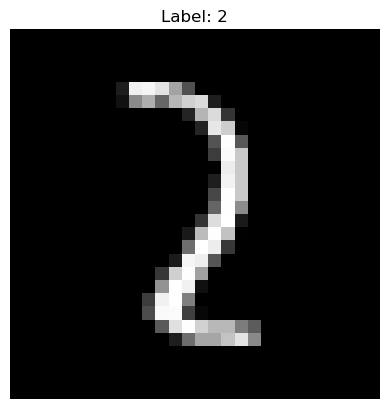

In [ ]:
# OUTPUT TEST EXAMPLE
# indice immagine da visualizzare (ricordarsi che gli esempi sono sulle colonne e non sulle righe --> trasposta)
index = 50

image = X_test[:, index].reshape(28, 28)

plt.imshow(image.get(), cmap='gray')
plt.title(f"Label: {Y_test[index]}")
plt.axis('off')
plt.show()

### Class-Unified Versions

#### First Net (Class)

In [ ]:
class MLP:
    def __init__(self):
        self.W1 = np.random.rand(64, 784) - 0.5
        self.b1 = np.random.rand(64, 1) - 0.5
        self.W2 = np.random.rand(10, 64) - 0.5
        self.b2 = np.random.rand(10, 1) - 0.5

    def ReLU(self, Z):
        return np.maximum(0, Z)

    def softmax(self, Z):
        Z = Z - np.max(Z, axis=0, keepdims=True)
        expZ = np.exp(Z)
        return expZ / np.sum(expZ, axis=0, keepdims=True)

    def forward(self, X):
        Z1 = self.W1.dot(X) + self.b1
        A1 = self.ReLU(Z1)
        Z2 = self.W2.dot(A1) + self.b2
        A2 = self.softmax(Z2)
        return Z1, A1, Z2, A2

    def one_hot(self, Y):
        one_hot_Y = np.zeros((Y.size, 10))
        one_hot_Y[np.arange(Y.size), Y] = 1
        return one_hot_Y.T

    def backward(self, Z1, A1, A2, X, Y):
        m = Y.size
        one_hot_Y = self.one_hot(Y)

        dZ2 = A2 - one_hot_Y
        dW2 = (1/m) * dZ2.dot(A1.T)
        db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

        dZ1 = self.W2.T.dot(dZ2) * (Z1 > 0)
        dW1 = (1/m) * dZ1.dot(X.T)
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

        return dW1, db1, dW2, db2

    def update(self, dW1, db1, dW2, db2, alpha):
        self.W1 -= alpha * dW1
        self.b1 -= alpha * db1
        self.W2 -= alpha * dW2
        self.b2 -= alpha * db2

    def train(self, X, Y, iterations, alpha):
        for _ in range(iterations):
            Z1, A1, _, A2 = self.forward(X)
            dW1, db1, dW2, db2 = self.backward(Z1, A1, A2, X, Y)
            self.update(dW1, db1, dW2, db2, alpha)

        print("Train accuracy:", self.accuracy(X, Y))

    def predict(self, X):
        _, _, _, A2 = self.forward(X)
        return np.argmax(A2, axis=0)

    def accuracy(self, X, Y):
        preds = self.predict(X)
        return np.sum(preds == Y) / Y.size

In [44]:
model = MLP()

model.train(X_train, Y_train, 1500, 0.01)
print("Test accuracy:", model.accuracy(X_test, Y_test))

Train accuracy: 0.8406
Test accuracy: 0.8475


#### GPU-Optimized

In [ ]:
# 30 secondi invece che 5 minuti e mezzo (330 secondi)
# meno operazioni piccole, più operazioni matriciali, meno sync non GPU

# MODIFICHE: aggiunta di un layer
# 764 -> 64 -> 32 -> 10
# X -> W1 -> ReLU -> W2 -> ReLU -> W3 -> Softmax

In [5]:
class MLPGPU:
    def __init__(self):
        self.W1 = (np.random.rand(64, 784).astype(np.float32) - 0.5)
        self.b1 = (np.random.rand(64, 1).astype(np.float32) - 0.5)
        self.W2 = (np.random.rand(32, 64).astype(np.float32) - 0.5)
        self.b2 = (np.random.rand(32, 1).astype(np.float32) - 0.5)
        self.W3 = (np.random.rand(10, 32).astype(np.float32) - 0.5)
        self.b3 = (np.random.rand(10, 1).astype(np.float32) - 0.5)

    def train(self, X, Y, iterations, alpha):
        X = X.astype(np.float32)

        m = Y.size

        one_hot_Y = np.zeros((10, m), dtype=np.float32)
        one_hot_Y[Y, np.arange(m)] = 1

        for _ in range(iterations):
            # ===== FORWARD (tutto inline, meno overhead) =====
            # la chiocciola @ è l'operazione di moltiplicazione tra matrici
            Z1 = self.W1 @ X + self.b1
            A1 = np.maximum(Z1, 0)

            Z2 = self.W2 @ A1 + self.b2
            A2 = np.maximum(Z2, 0)
            
            Z3 = self.W3 @ A2 + self.b3

            # softmax stabile
            Z3 -= np.max(Z3, axis=0, keepdims=True)
            expZ = np.exp(Z3)
            A3 = expZ / np.sum(expZ, axis=0, keepdims=True)

            # ===== BACKWARD =====
            dZ3 = A3 - one_hot_Y
            dW3 = (dZ3 @ A2.T) / m
            db3 = np.sum(dZ3, axis=1, keepdims=True) / m
            
            dZ2 = (self.W3.T @ dZ3) * (Z2 > 0)
            dW2 = (dZ2 @ A1.T) / m
            db2 = np.sum(dZ2, axis=1, keepdims=True) / m

            dZ1 = (self.W2.T @ dZ2) * (Z1 > 0)
            dW1 = (dZ1 @ X.T) / m
            db1 = np.sum(dZ1, axis=1, keepdims=True) / m

            # ===== UPDATE =====
            self.W1 -= alpha * dW1
            self.b1 -= alpha * db1
            self.W2 -= alpha * dW2
            self.b2 -= alpha * db2
            self.W3 -= alpha * dW3
            self.b3 -= alpha * db3

        preds = np.argmax(A3, axis=0)
        acc = np.mean(preds == Y)

        print("Train accuracy:", float(acc))  # sync qui

    def predict(self, X):
        X = X.astype(np.float32)

        Z1 = self.W1 @ X + self.b1
        A1 = np.maximum(Z1, 0)

        Z2 = self.W2 @ A1 + self.b2
        A2 = np.maximum(Z2, 0)
        
        Z3 = self.W3 @ A2 + self.b3
        Z3 -= np.max(Z3, axis=0, keepdims=True)

        expZ = np.exp(Z3)
        A3 = expZ / np.sum(expZ, axis=0, keepdims=True)

        return np.argmax(A3, axis=0)

    def accuracy(self, X, Y):
        preds = self.predict(X)
        return float(np.mean(preds == Y)) 

In [19]:
model = MLPGPU()

model.train(X_train, Y_train, 2000, 0.001)
print("Test accuracy:", model.accuracy(X_test, Y_test))

Train accuracy: 0.6030333333333333
Test accuracy: 0.62


In [ ]:
# usato learning rate troppo basso per il numero di iterazioni
# ma è per fare un confronto con l'optimizer successivo

#### ADAM-Optimizer + Dropout (First Hidden Layer)

In [ ]:
# L'ADAM-optimizer combina il Momentum (media dei gradienti) 
# e l'RMSProp (scala adattiva per la grandezza dei gradienti)

# In pratica, non usa solo il gradiente attuale, ma anche la storia dei gradienti (media dei gradienti passati)
# m --> direzione media (come velocità)
# v --> quanto è grande il gradiente
# i parametri con gradienti grandi fanno aggiornamenti piccoli, quelli con gradienti piccoli fanno aggiornamenti grandi

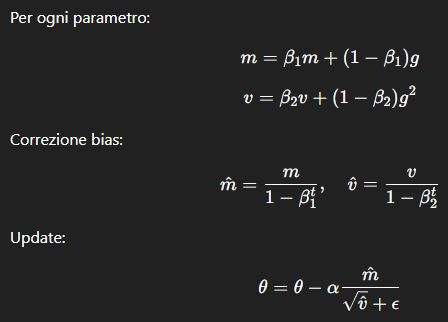

In [21]:
class MLPADAM:
    def __init__(self):
        self.W1 = (np.random.rand(64, 784).astype(np.float32) - 0.5)
        self.b1 = (np.random.rand(64, 1).astype(np.float32) - 0.5)
        self.W2 = (np.random.rand(32, 64).astype(np.float32) - 0.5)
        self.b2 = (np.random.rand(32, 1).astype(np.float32) - 0.5)
        self.W3 = (np.random.rand(10, 32).astype(np.float32) - 0.5)
        self.b3 = (np.random.rand(10, 1).astype(np.float32) - 0.5)
        
        # Momenti ADAM
        self.mW1 = np.zeros_like(self.W1)
        self.vW1 = np.zeros_like(self.W1)
        self.mb1 = np.zeros_like(self.b1)
        self.vb1 = np.zeros_like(self.b1)

        self.mW2 = np.zeros_like(self.W2)
        self.vW2 = np.zeros_like(self.W2)
        self.mb2 = np.zeros_like(self.b2)
        self.vb2 = np.zeros_like(self.b2)

        self.mW3 = np.zeros_like(self.W3)
        self.vW3 = np.zeros_like(self.W3)
        self.mb3 = np.zeros_like(self.b3)
        self.vb3 = np.zeros_like(self.b3)

    def train(self, X, Y, iterations, alpha):
        X = X.astype(np.float32)

        m = Y.size

        one_hot_Y = np.zeros((10, m), dtype=np.float32)
        one_hot_Y[Y, np.arange(m)] = 1
        
        # parametri ADAM
        beta1 = 0.9
        beta2 = 0.999
        eps = 1e-8
        t = 0  # timestep

        for _ in range(iterations):
            t += 1
            # ===== FORWARD =====
            Z1 = self.W1 @ X + self.b1
            A1 = np.maximum(Z1, 0)
            
            # DROPOUT 
            # (*A1 = unpack della tupla e confronto con 0.2 == matrice booleana)
            # effetto: 20% di probabilità di spegnere alcuni neuroni nel primo hidden layer
            dropout_mask = (np.random.rand(*A1.shape) > 0.2).astype(np.float32)
            A1 *= dropout_mask
            A1 /= (1 - 0.2) 

            Z2 = self.W2 @ A1 + self.b2
            A2 = np.maximum(Z2, 0)
            
            Z3 = self.W3 @ A2 + self.b3

            # softmax stabile
            Z3 -= np.max(Z3, axis=0, keepdims=True)
            expZ = np.exp(Z3)
            A3 = expZ / np.sum(expZ, axis=0, keepdims=True)

            # ===== BACKWARD =====
            dZ3 = A3 - one_hot_Y
            dW3 = (dZ3 @ A2.T) / m
            db3 = np.sum(dZ3, axis=1, keepdims=True) / m
            
            dZ2 = (self.W3.T @ dZ3) * (Z2 > 0)
            dW2 = (dZ2 @ A1.T) / m
            db2 = np.sum(dZ2, axis=1, keepdims=True) / m

            dZ1 = (self.W2.T @ dZ2) * (Z1 > 0)
            dW1 = (dZ1 @ X.T) / m
            db1 = np.sum(dZ1, axis=1, keepdims=True) / m

            # ===== ADAM UPDATE =====
            # W1
            self.mW1 = beta1 * self.mW1 + (1 - beta1) * dW1
            self.vW1 = beta2 * self.vW1 + (1 - beta2) * (dW1 ** 2)
            mW1_hat = self.mW1 / (1 - beta1**t)
            vW1_hat = self.vW1 / (1 - beta2**t)
            self.W1 -= alpha * mW1_hat / (np.sqrt(vW1_hat) + eps)
            # b1
            self.mb1 = beta1 * self.mb1 + (1 - beta1) * db1
            self.vb1 = beta2 * self.vb1 + (1 - beta2) * (db1 ** 2)
            mb1_hat = self.mb1 / (1 - beta1**t)
            vb1_hat = self.vb1 / (1 - beta2**t)
            self.b1 -= alpha * mb1_hat / (np.sqrt(vb1_hat) + eps)
            # W2
            self.mW2 = beta1 * self.mW2 + (1 - beta1) * dW2
            self.vW2 = beta2 * self.vW2 + (1 - beta2) * (dW2 ** 2)
            mW2_hat = self.mW2 / (1 - beta1**t)
            vW2_hat = self.vW2 / (1 - beta2**t)
            self.W2 -= alpha * mW2_hat / (np.sqrt(vW2_hat) + eps)
            # b2
            self.mb2 = beta1 * self.mb2 + (1 - beta1) * db2
            self.vb2 = beta2 * self.vb2 + (1 - beta2) * (db2 ** 2)
            mb2_hat = self.mb2 / (1 - beta1**t)
            vb2_hat = self.vb2 / (1 - beta2**t)
            self.b2 -= alpha * mb2_hat / (np.sqrt(vb2_hat) + eps)
            # W3
            self.mW3 = beta1 * self.mW3 + (1 - beta1) * dW3
            self.vW3 = beta2 * self.vW3 + (1 - beta2) * (dW3 ** 2)
            mW3_hat = self.mW3 / (1 - beta1**t)
            vW3_hat = self.vW3 / (1 - beta2**t)
            self.W3 -= alpha * mW3_hat / (np.sqrt(vW3_hat) + eps)
           # b3
            self.mb3 = beta1 * self.mb3 + (1 - beta1) * db3
            self.vb3 = beta2 * self.vb3 + (1 - beta2) * (db3 ** 2)
            mb3_hat = self.mb3 / (1 - beta1**t)
            vb3_hat = self.vb3 / (1 - beta2**t)
            self.b3 -= alpha * mb3_hat / (np.sqrt(vb3_hat) + eps)

        preds = np.argmax(A3, axis=0)
        acc = np.mean(preds == Y)

        print("Train accuracy:", float(acc))  # sync qui

    def predict(self, X):
        X = X.astype(np.float32)

        Z1 = self.W1 @ X + self.b1
        A1 = np.maximum(Z1, 0)

        Z2 = self.W2 @ A1 + self.b2
        A2 = np.maximum(Z2, 0)
        
        Z3 = self.W3 @ A2 + self.b3
        Z3 -= np.max(Z3, axis=0, keepdims=True)

        expZ = np.exp(Z3)
        A3 = expZ / np.sum(expZ, axis=0, keepdims=True)

        return np.argmax(A3, axis=0)

    def accuracy(self, X, Y):
        preds = self.predict(X)
        return float(np.mean(preds == Y)) 

In [22]:
model = MLPADAM()

model.train(X_train, Y_train, 2000, 0.001)
print("Test accuracy:", model.accuracy(X_test, Y_test))

Train accuracy: 0.9328833333333333
Test accuracy: 0.952


#### ADAM-Optimizer + Mini-Batch + N-Layer Generalization + Dropout (First-Hidden) + BatchNorm

In [ ]:
# La Batch Normalization normalizza gli input di ogni strato della rete neurale per ogni "mini-batch" di dati
# Calcola media e varianza dei valori di attivazione per il mini-batch corrente
# Normalizza i dati sottraendo la media e dividendo per la deviazione standard

# Addestramento più veloce: Permette di utilizzare tassi di apprendimento (learning rates) più alti senza il rischio di divergenza.
# Maggiore stabilità: Riduce l'internal covariate shift, ovvero il fenomeno per cui la distribuzione degli input di uno strato cambia continuamente mentre i parametri degli strati precedenti si aggiornano.


In [2]:
class Adam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0

        # momenti per ogni parametro
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]

    def step(self, params, grads):
        self.t += 1

        for i in range(len(params)):
            g = grads[i]

            # momentum
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g

            # rms
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g ** 2)

            # bias correction
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            # update
            params[i] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

In [3]:
class LinearNN:
    def __init__(self, layers, dropout_rate=0.4, l2_lambda=1e-4):
        self.L = len(layers) - 1
        self.dropout_rate = dropout_rate
        self.training = True

        self.eps = 1e-5
        self.momentum = 0.9
        self.l2_lambda = l2_lambda

        # Parametri
        self.W = []
        self.b = []
        self.gamma = []
        self.beta = []

        self.running_mean = []
        self.running_var = []

        for i in range(self.L):
            self.W.append(
                (np.random.randn(layers[i+1], layers[i]).astype(np.float32)
                 * np.sqrt(2. / layers[i]))
            )
            self.b.append(np.zeros((layers[i+1], 1), dtype=np.float32))

            if i < self.L - 1:
                self.gamma.append(np.ones((layers[i+1], 1), dtype=np.float32))
                self.beta.append(np.zeros((layers[i+1], 1), dtype=np.float32))

                self.running_mean.append(np.zeros((layers[i+1], 1), dtype=np.float32))
                self.running_var.append(np.ones((layers[i+1], 1), dtype=np.float32))

    # =========================
    # FORWARD
    # =========================
    def forward(self, X):
        A = X
        As = [X]
        Zs = []

        self.cache_bn = []

        for i in range(self.L - 1):
            Z = self.W[i] @ A + self.b[i]

            # BatchNorm
            if self.training:
                mean = np.mean(Z, axis=1, keepdims=True)
                var = np.mean((Z - mean) ** 2, axis=1, keepdims=True)

                self.running_mean[i] = (
                    self.momentum * self.running_mean[i]
                    + (1 - self.momentum) * mean
                )
                self.running_var[i] = (
                    self.momentum * self.running_var[i]
                    + (1 - self.momentum) * var
                )
            else:
                mean = self.running_mean[i]
                var = self.running_var[i]

            std_inv = 1. / np.sqrt(var + self.eps)
            Z_norm = (Z - mean) * std_inv
            Z_tilde = self.gamma[i] * Z_norm + self.beta[i]

            self.cache_bn.append((Z_norm, std_inv))

            # ===== Leaky ReLU =====
            A = np.maximum(0.01 * Z_tilde, Z_tilde)

            Zs.append(Z_tilde)
            As.append(A)

        # ===== Output (softmax ottimizzata) =====
        Z = self.W[-1] @ A + self.b[-1]
        Z -= Z.max(axis=0, keepdims=True)

        np.exp(Z, out=Z)
        Z /= Z.sum(axis=0, keepdims=True)
        A = Z

        Zs.append(Z)
        As.append(A)

        return Zs, As

    # =========================
    # BACKWARD
    # =========================
    def backward(self, Zs, As, Y):
        m = As[-1].shape[1]

        dW = [None] * self.L
        db = [None] * self.L
        dgamma = [None] * (self.L - 1)
        dbeta = [None] * (self.L - 1)

        # Softmax gradient (NO one-hot)
        dZ = As[-1].copy()
        dZ[Y, np.arange(m)] -= 1
        dZ /= m

        for i in reversed(range(self.L)):
            # L2 regularization
            dW[i] = (dZ @ As[i].T) + self.l2_lambda * self.W[i]
            db[i] = np.sum(dZ, axis=1, keepdims=True)

            if i > 0:
                dA = self.W[i].T @ dZ

                # Leaky ReLU backward
                dZ = dA * (Zs[i-1] > 0) + 0.01 * dA * (Zs[i-1] <= 0)

                # BatchNorm
                Z_norm, std_inv = self.cache_bn[i-1]
                gamma = self.gamma[i-1]

                dgamma[i-1] = np.sum(dZ * Z_norm, axis=1, keepdims=True)
                dbeta[i-1] = np.sum(dZ, axis=1, keepdims=True)

                dZ_norm = dZ * gamma

                dZ = (1. / m) * std_inv * (
                    m * dZ_norm
                    - np.sum(dZ_norm, axis=1, keepdims=True)
                    - Z_norm * np.sum(dZ_norm * Z_norm, axis=1, keepdims=True)
                )

        # ===== Gradient clipping =====
        for i in range(self.L):
            np.clip(dW[i], -1.0, 1.0, out=dW[i])
            np.clip(db[i], -1.0, 1.0, out=db[i])

        return dW + db + dgamma + dbeta

    # =========================
    # PARAMS
    # =========================
    def get_params(self):
        return self.W + self.b + self.gamma + self.beta

    # =========================
    # TRAIN
    # =========================
    def train(self, X, Y, epochs, batch_size, optimizer, lr_decay=0.95):
        for epoch in range(epochs):
            self.training = True

            # LR scheduling
            optimizer.lr *= lr_decay

            m = X.shape[1]
            perm = np.random.permutation(m)
            X = X[:, perm]
            Y = Y[perm]

            for i in range(0, m, batch_size):
                Xb = X[:, i:i+batch_size]
                Yb = Y[i:i+batch_size]

                Zs, As = self.forward(Xb)
                grads = self.backward(Zs, As, Yb)

                optimizer.step(self.get_params(), grads)

        self.training = False
        acc = self.accuracy(X, Y)
        print(f"Train Accuracy: {acc}")

    # =========================
    # PREDICT
    # =========================
    def predict(self, X):
        self.training = False
        _, As = self.forward(X)
        return np.argmax(As[-1], axis=0)

    def accuracy(self, X, Y):
        preds = self.predict(X)
        return float(np.mean(preds == Y))

In [8]:
layers = [784, 64, 32, 10]
model = LinearNN(layers)

optimizer = Adam(model.get_params(), lr=0.001)
model.train(X_train, Y_train,
            epochs=20,
            batch_size=128,
            optimizer=optimizer)

print("Test accuracy:", model.accuracy(X_test, Y_test))

Train Accuracy: 0.9994666666666666
Test accuracy: 0.9722


## Testing

#### KMNIST

In [4]:
X_train = np.load("kmnist/kmnist-train-imgs.npz")["arr_0"]
X_test = np.load("kmnist/kmnist-test-imgs.npz")["arr_0"]
Y_train = np.load("kmnist/kmnist-train-labels.npz")["arr_0"]
Y_test = np.load("kmnist/kmnist-test-labels.npz")["arr_0"]

In [5]:
X_train = np.array(X_train.reshape(-1, 28*28).T, dtype=np.float32) / 255.0
Y_train = np.array(Y_train)

X_test = np.array(X_test.reshape(-1, 28*28).T, dtype=np.float32) / 255.0
Y_test = np.array(Y_test)

In [6]:
# Normalization
mean = np.mean(X_train)
std  = np.std(X_train) + 1e-8

X_train = (X_train - mean) / std
X_test  = (X_test - mean) / std

In [7]:
layers = [784, 64, 32, 10]
model = LinearNN(layers)

optimizer = Adam(model.get_params(), lr=0.001)
model.train(X_train, Y_train,
            epochs=20,
            batch_size=128,
            optimizer=optimizer)

print("Test accuracy:", model.accuracy(X_test, Y_test))

Train Accuracy: 0.9969666666666667
Test accuracy: 0.8731


In [10]:
layers = [784, 128, 64, 32, 10]
model = LinearNN(layers)

optimizer = Adam(model.get_params(), lr=0.01)
model.train(X_train, Y_train,
            epochs=20,
            batch_size=512,
            optimizer=optimizer)

print("Test accuracy:", model.accuracy(X_test, Y_test))

Train Accuracy: 0.9968
Test accuracy: 0.9018


#### HIGGS

In [8]:
# =========================
# LOAD CSV
# =========================
df = pd.read_csv("HIGGS.csv", nrows=500_000, header=None)

data = np.array(df.values, dtype=np.float32)

# =========================
# SHUFFLE (importantissimo)
# =========================
np.random.shuffle(data)

# =========================
# SPLIT TRAIN / TEST
# =========================
split_ratio = 0.8
split = int(split_ratio * data.shape[0])

train_data = data[:split]
test_data  = data[split:]

# =========================
# SEPARA X e Y
# =========================
# label = prima colonna
X_train = train_data[:, 1:]
Y_train = train_data[:, 0]

X_test  = test_data[:, 1:]
Y_test  = test_data[:, 0]

# =========================
# TRASFORMA per la tua rete
# (features, samples)
# =========================
X_train = X_train.T
X_test  = X_test.T

# =========================
# CONVERSIONE TIPI GPU
# =========================
X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

Y_train = Y_train.astype(np.int32)
Y_test  = Y_test.astype(np.int32)

# =========================
# NORMALIZZAZIONE
# =========================
mean = np.mean(X_train, axis=1, keepdims=True)
std  = np.std(X_train, axis=1, keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test  = (X_test - mean) / std

In [9]:
X_train = np.array(X_train)
X_test  = np.array(X_test)
Y_train = np.array(Y_train)
Y_test  = np.array(Y_test)

In [10]:
num_features = 28
num_classes = 2
layers = [num_features, 512, 256, 128, 64, num_classes]
model = LinearNN(layers, dropout_rate=0.0)

optimizer = Adam(model.get_params(), lr=0.0003)
model.train(X_train, Y_train,
            epochs=20,
            batch_size=4096,
            optimizer=optimizer)

print("Test accuracy:", model.accuracy(X_test, Y_test))

KeyboardInterrupt: 